"Изучить и реализовать MLP (многослойная искусственная нейронная сеть) для классификации нелинейно разделимых данных.

1. Сгенерируйте данные (любым методом из sklearn.datasets).
2. Визуализируйте данные на плоскости.
3. Создайте MLP: вход (2 нейрона), скрытый слой (4 нейрона, ReLU), выход (1 нейрон, sigmoid) - можете использовать pytorch / keras
4. Разделите данные (80% — обучение, 20% — тест).
5. Обучите на 1000 эпох, постройте график потерь.
6. Оцените точность на тесте.
7.Если увлеклись, можно реализовать MLP для решения XOR"

In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 1 Пункт

In [20]:
# 1) генерация данных
rng = 42
X, y = make_moons(n_samples=600, noise=0.2, random_state=rng)  # двумерные признаки и метки {0,1} [web:14]
X = X.astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

## 2 Пункт

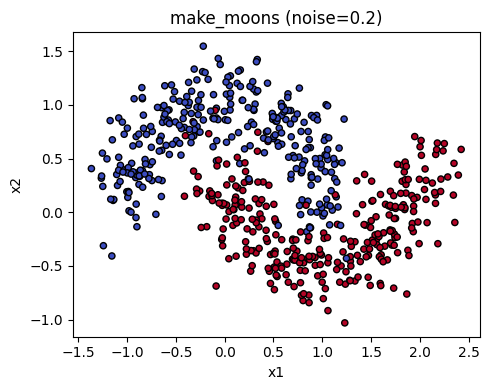

In [21]:
# 2) Визуализация данных
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', s=20, edgecolor='k')
plt.title("make_moons (noise=0.2)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout(); plt.show()  # make_moons предоставляет 2D точки двух «полумесяцев» [web:14]

## 3 Пункт

In [22]:
# 3) Определение MLP: 2 -> 4 (ReLU) -> 1 (sigmoid)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),              # скрытый слой с ReLU
            nn.Linear(4, 1)         # логиты
        )
    def forward(self, x):
        return self.net(x)

## 4 пункт

In [23]:
# 4) Разделение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rng, stratify=y
)  # 80/20 — распространённая пропорция, задаётся через test_size=0.2 [web:25][web:22]

model = MLP()

# Используем BCEWithLogitsLoss: сочетает сигмоиду и BCE в одной функции, численно стабильнее
criterion = nn.BCEWithLogitsLoss()  # не добавляйте явную sigmoid перед этой функцией [web:30][web:21][web:18]
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# Подготовка тензоров
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

## 5 Пункт

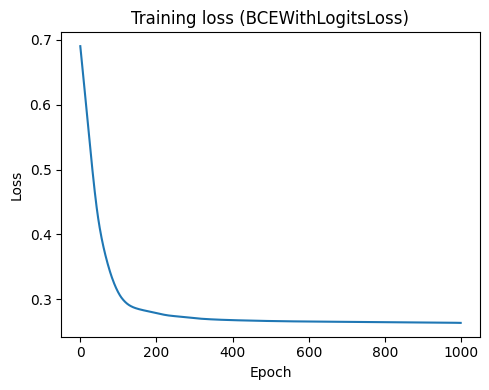

In [24]:
# 5) Обучение 1000 эпох и сбор истории потерь
n_epochs = 1000
loss_hist = []

model.train()
for epoch in range(1, n_epochs+1):
    optimizer.zero_grad()
    logits = model(X_train_t)                  # логиты
    loss = criterion(logits, y_train_t)        # BCE с логитами (внутри есть sigmoid) [web:30]
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())

# График потерь
plt.figure(figsize=(5,4))
plt.plot(loss_hist)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training loss (BCEWithLogitsLoss)")
plt.tight_layout(); plt.show()  # Нормально использовать BCEWithLogitsLoss для бинарной классификации [web:30]

## 6 Пункт

In [25]:
# 6) Оценка точности на тесте
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_prob = torch.sigmoid(test_logits)     # для метрик переводим логиты в вероятности [web:30]
    y_pred = (test_prob >= 0.5).float()
    test_acc = (y_pred.eq(y_test_t).float().mean().item())

print(f"Test accuracy: {test_acc:.4f}")  # Разбиение train_test_split — стандартный путь к оценке на отложенной выборке [web:25]

Test accuracy: 0.9000
